# SPXTR Forward Returns vs. VIX & SKEW

Does the level of implied volatility (VIX) or tail-risk pricing (CBOE SKEW) tell us anything about
subsequent S&P 500 Total Return (SPXTR) performance?

This notebook:
1. Loads daily SPXTR close, VIX, and SKEW from `data/tradingview/us_vol_data/spxtr_vix_skew.csv`.
2. Builds forward SPXTR returns at several horizons (1w, 1m, 3m, 6m, 12m).
3. Builds trailing z-scores of VIX and SKEW (63d and 252d rolling windows) alongside the raw levels.
4. Visualizes the raw series, their relationship with forward returns, and quintile-sorted forward
   returns.
5. Tests statistical significance via Pearson/Spearman correlation and Newey-West (HAC) OLS
   regression - univariate and combined - to see whether VIX, SKEW, or the pair together carry
   forecasting power for forward SPXTR returns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)

DATA_PATH = '../data/tradingview/us_vol_data/spxtr_vix_skew.csv'

## 1. Load and clean data

The raw file has SPXTR OHLC plus two extra columns for CBOE SKEW and VIX close prices, keyed by a
Unix timestamp. VIX/SKEW history only starts in January 1990, so rows before both series exist are
dropped.

In [2]:
raw = pd.read_csv(DATA_PATH)
df = raw.rename(columns={
    'close': 'spxtr',
    'CBOE SKEW INDEX · CBOE: close': 'skew',
    'Volatility S&P 500 Index · TVC: close': 'vix',
})
df['date'] = pd.to_datetime(df['time'], unit='s')
df = df[['date', 'spxtr', 'vix', 'skew']].sort_values('date').reset_index(drop=True)

n_before = len(df)
df = df.dropna(subset=['vix', 'skew']).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows before VIX/SKEW history begins.")
print(f"Sample: {df['date'].min().date()} -> {df['date'].max().date()}  ({len(df)} obs)")
df.describe()

Dropped 575 rows before VIX/SKEW history begins.
Sample: 1990-01-03 -> 2026-09-11  (9175 obs)


,date,spxtr,vix,skew
count,9175,9175.000000,9175.000000,9175.000000
mean,2008-04-18 22:56:11.836512,3610.746291,19.452811,123.152445
min,1990-01-03 14:30:00,326.080000,9.140000,101.230000
25%,1999-02-04 02:30:00,1336.800000,14.000000,114.770000
50%,2008-04-03 13:30:00,1983.730000,17.610000,119.860000
75%,2017-07-02 01:30:00,4697.870000,22.719995,128.320000
max,2026-09-11 13:30:00,17460.760000,82.690000,183.120000
std,NaN,3717.778434,7.741154,11.701465


## 2. Build forward returns and trailing z-scores

- **Forward returns**: `spxtr[t+h] / spxtr[t] - 1` for horizons of 1 week, 1/3/6/12 months
  (5/21/63/126/252 trading days). These are overlapping, so later significance tests use
  autocorrelation-robust (Newey-West/HAC) standard errors.
- **Trailing z-scores**: `(x - rolling_mean(x)) / rolling_std(x)` over 63d (~1 quarter) and 252d
  (~1 year) windows, computed *only on trailing data* so there is no look-ahead bias - the z-score
  at time `t` uses only information available at `t`.

In [3]:
HORIZONS = {'1w': 5, '1m': 21, '3m': 63, '6m': 126, '12m': 252}
Z_WINDOWS = [63, 252]

for name, h in HORIZONS.items():
    df[f'fwd_ret_{name}'] = df['spxtr'].shift(-h) / df['spxtr'] - 1

for col in ['vix', 'skew']:
    for w in Z_WINDOWS:
        roll = df[col].rolling(w)
        df[f'{col}_z{w}'] = (df[col] - roll.mean()) / roll.std()

fwd_cols = [f'fwd_ret_{n}' for n in HORIZONS]
z_cols = [f'{c}_z{w}' for c in ['vix', 'skew'] for w in Z_WINDOWS]
df[['date', 'vix', 'skew'] + z_cols + fwd_cols].tail()

,date,vix,skew,vix_z63,vix_z252,skew_z63,skew_z252,fwd_ret_1w,fwd_ret_1m,fwd_ret_3m,fwd_ret_6m,fwd_ret_12m
9170,2026-09-04 13:30:00,14.52,151.58,-1.229827,-1.087588,1.547798,1.250792,NaN,NaN,NaN,NaN,NaN
9171,2026-09-08 13:30:00,15.71,148.86,-0.523528,-0.727433,0.997950,0.753059,NaN,NaN,NaN,NaN,NaN
9172,2026-09-09 13:30:00,16.47,149.25,-0.052183,-0.498892,1.042597,0.824508,NaN,NaN,NaN,NaN,NaN
9173,2026-09-10 13:30:00,17.85,147.02,0.899958,-0.083144,0.600970,0.410481,NaN,NaN,NaN,NaN,NaN
9174,2026-09-11 13:30:00,15.85,154.49,-0.395610,-0.693246,1.933839,1.794372,NaN,NaN,NaN,NaN,NaN


## 3. Raw series over time

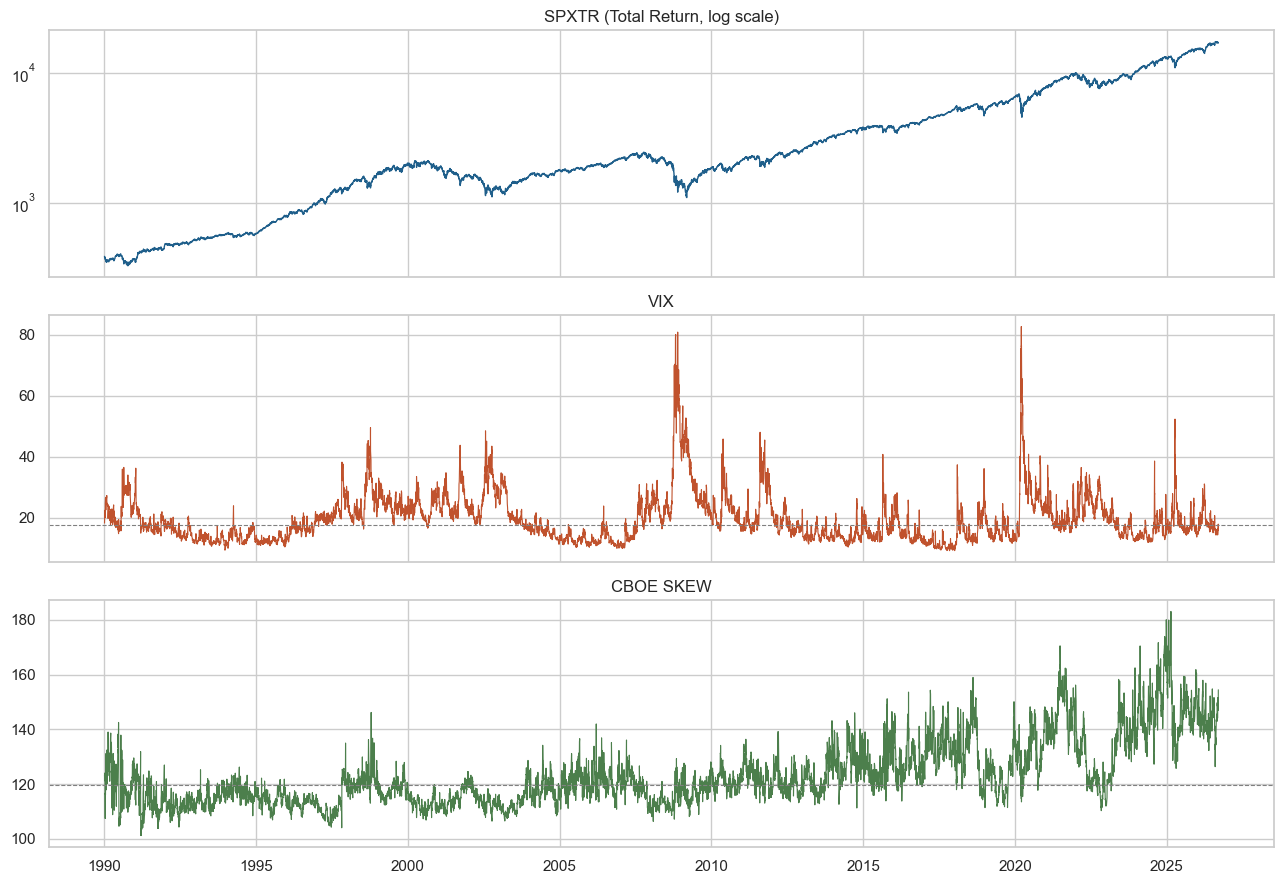

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(df['date'], df['spxtr'], color='#1f5f8b', lw=1)
axes[0].set_yscale('log')
axes[0].set_title('SPXTR (Total Return, log scale)')

axes[1].plot(df['date'], df['vix'], color='#c0522d', lw=0.8)
axes[1].axhline(df['vix'].median(), color='gray', ls='--', lw=0.8)
axes[1].set_title('VIX')

axes[2].plot(df['date'], df['skew'], color='#4c7f4c', lw=0.8)
axes[2].axhline(df['skew'].median(), color='gray', ls='--', lw=0.8)
axes[2].set_title('CBOE SKEW')
axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

## 4. Trailing z-scores over time

252-day z-scores of VIX and SKEW, shaded above +1 to flag "elevated fear" regimes.

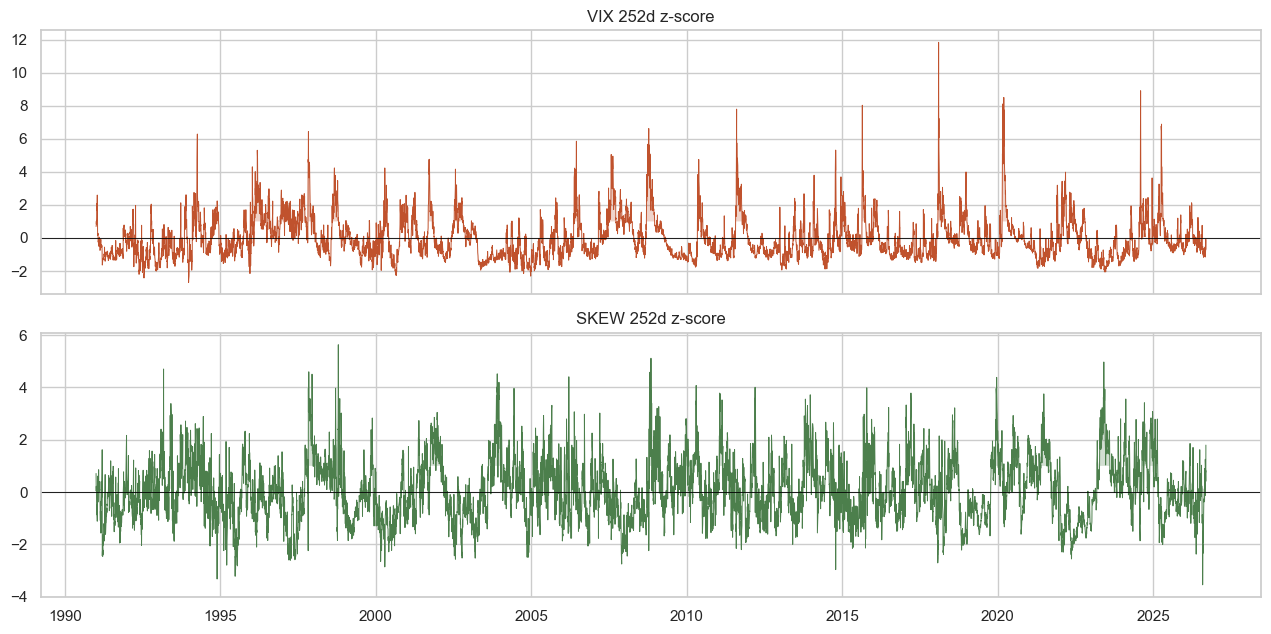

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)

for ax, col, color, title in [
    (axes[0], 'vix_z252', '#c0522d', 'VIX 252d z-score'),
    (axes[1], 'skew_z252', '#4c7f4c', 'SKEW 252d z-score'),
]:
    ax.plot(df['date'], df[col], color=color, lw=0.7)
    ax.axhline(0, color='black', lw=0.6)
    ax.fill_between(df['date'], 1, df[col].clip(lower=1), where=df[col] > 1,
                    color=color, alpha=0.25, lw=0)
    ax.set_title(title)

axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

## 5. Predictor vs. forward return scatter plots

Raw level (top row) and 252d z-score (bottom row) of each predictor against forward SPXTR returns,
across horizons. A LOWESS trend line highlights any non-trivial relationship.

### 5.1 VIX

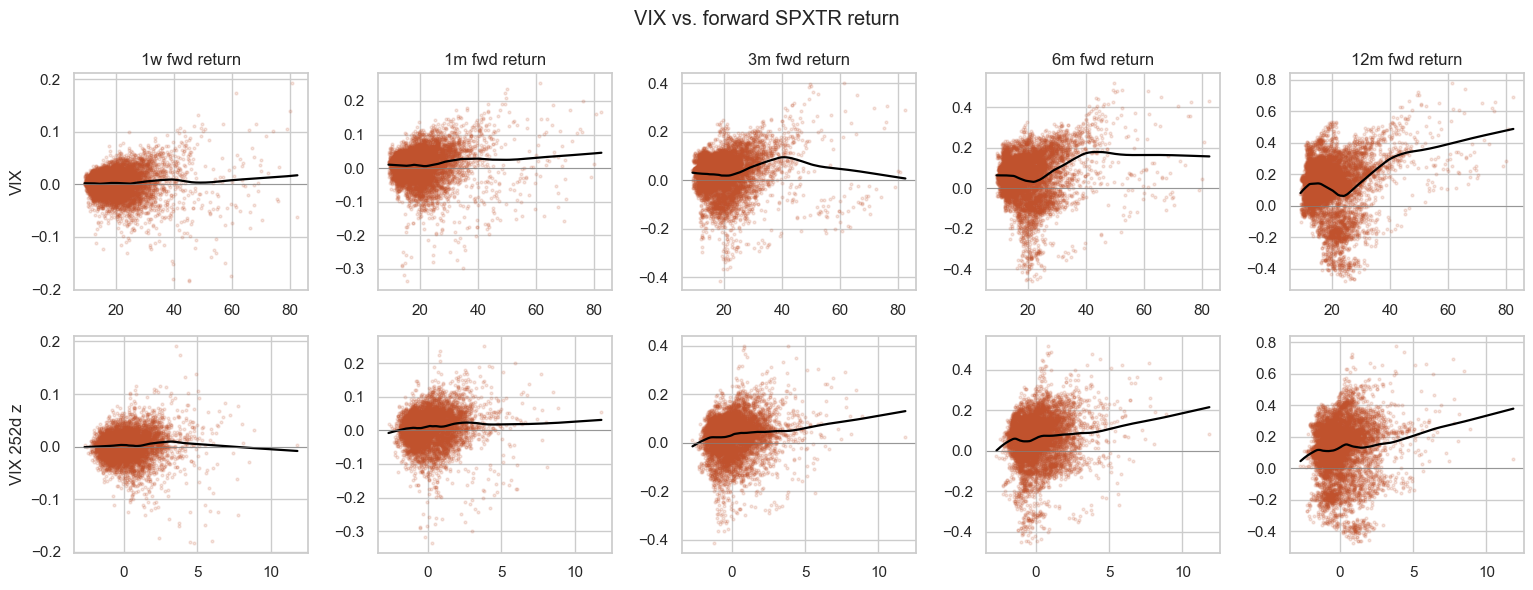

In [6]:
def plot_predictor_grid(predictor_raw, predictor_z, label, color):
    fig, axes = plt.subplots(2, len(HORIZONS), figsize=(3.1 * len(HORIZONS), 6), sharex='row')
    for row, pred_col, row_label in [(0, predictor_raw, label), (1, predictor_z, f'{label} 252d z')]:
        for ax, name in zip(axes[row], HORIZONS):
            sub = df[[pred_col, f'fwd_ret_{name}']].dropna()
            ax.scatter(sub[pred_col], sub[f'fwd_ret_{name}'], s=4, alpha=0.15, color=color)
            trend = lowess(sub[f'fwd_ret_{name}'], sub[pred_col], frac=0.3, it=0)
            ax.plot(trend[:, 0], trend[:, 1], color='black', lw=1.6)
            ax.axhline(0, color='gray', lw=0.5)
            if row == 0:
                ax.set_title(f'{name} fwd return')
            if ax is axes[row][0]:
                ax.set_ylabel(row_label)
    fig.suptitle(f'{label} vs. forward SPXTR return')
    fig.tight_layout()
    plt.show()


plot_predictor_grid('vix', 'vix_z252', 'VIX', '#c0522d')

### 5.2 SKEW

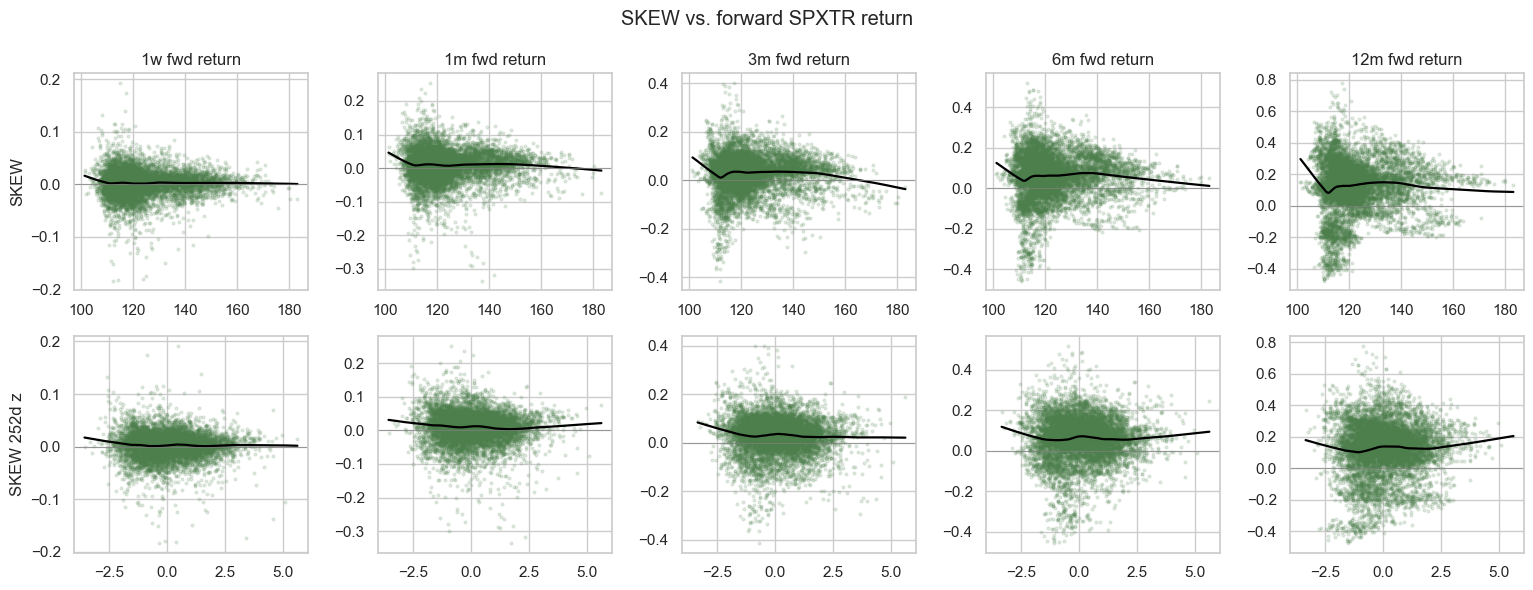

In [7]:
plot_predictor_grid('skew', 'skew_z252', 'SKEW', '#4c7f4c')

## 6. Quintile-sorted forward returns

Split each date into quintiles of the predictor (raw level and z-score), then look at the mean
3-month forward return per quintile with 95% CI error bars. If a predictor has forecasting power,
the bars should trend monotonically from Q1 (low) to Q5 (high).

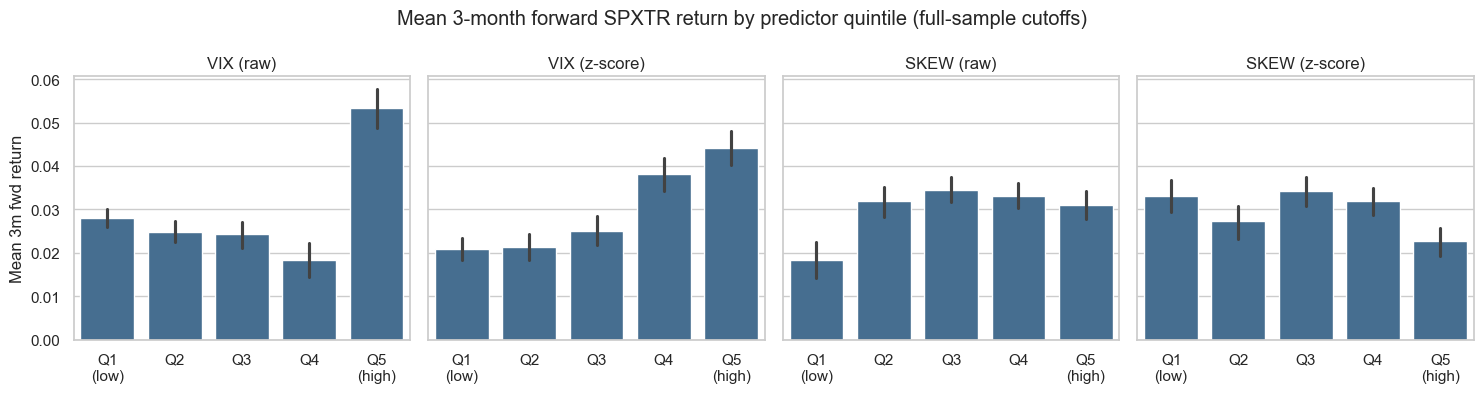

In [8]:
QUINTILE_HORIZON = '3m'
predictors = [('vix', 'VIX (raw)'), ('vix_z252', 'VIX (z-score)'),
              ('skew', 'SKEW (raw)'), ('skew_z252', 'SKEW (z-score)')]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for ax, (col, label) in zip(axes, predictors):
    sub = df[[col, f'fwd_ret_{QUINTILE_HORIZON}']].dropna().copy()
    sub['quintile'] = pd.qcut(sub[col], 5, labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
    sns.barplot(data=sub, x='quintile', y=f'fwd_ret_{QUINTILE_HORIZON}', errorbar=('ci', 95),
                ax=ax, color='#3a6f9c')
    ax.axhline(0, color='black', lw=0.7)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel(f'Mean {QUINTILE_HORIZON} fwd return' if ax is axes[0] else '')

fig.suptitle('Mean 3-month forward SPXTR return by predictor quintile (full-sample cutoffs)')
fig.tight_layout()
plt.show()

## 7. Correlation heatmap

Spearman rank correlation (robust to the non-normal, fat-tailed nature of returns and VIX/SKEW
levels) between each predictor and each forward-return horizon.

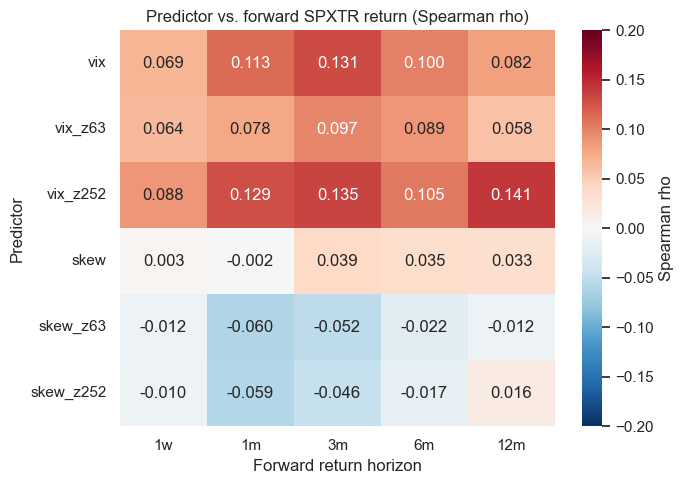

In [9]:
pred_cols = ['vix', 'vix_z63', 'vix_z252', 'skew', 'skew_z63', 'skew_z252']
corr = pd.DataFrame(index=pred_cols, columns=list(HORIZONS))
for p in pred_cols:
    for name in HORIZONS:
        sub = df[[p, f'fwd_ret_{name}']].dropna()
        corr.loc[p, name] = stats.spearmanr(sub[p], sub[f'fwd_ret_{name}']).statistic
corr = corr.astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-0.2, vmax=0.2, ax=ax,
            cbar_kws={'label': 'Spearman rho'})
ax.set_xlabel('Forward return horizon')
ax.set_ylabel('Predictor')
ax.set_title('Predictor vs. forward SPXTR return (Spearman rho)')
fig.tight_layout()
plt.show()

## 8. Statistical tests

### 8.1 Correlation significance (Pearson & Spearman)

p-values here treat observations as independent, which overstates significance for overlapping
forward returns - read them as an upper bound on significance, then cross-check against the
HAC-OLS results below which correct for the induced autocorrelation.

In [10]:
rows = []
for p in ['vix', 'vix_z252', 'skew', 'skew_z252']:
    for name in HORIZONS:
        sub = df[[p, f'fwd_ret_{name}']].dropna()
        pear = stats.pearsonr(sub[p], sub[f'fwd_ret_{name}'])
        spear = stats.spearmanr(sub[p], sub[f'fwd_ret_{name}'])
        rows.append({
            'predictor': p, 'horizon': name, 'n': len(sub),
            'pearson_r': pear.statistic, 'pearson_p': pear.pvalue,
            'spearman_rho': spear.statistic, 'spearman_p': spear.pvalue,
        })
corr_tests = pd.DataFrame(rows)
corr_tests['pearson_sig'] = corr_tests['pearson_p'] < 0.05
corr_tests['spearman_sig'] = corr_tests['spearman_p'] < 0.05
corr_tests.round(4)

,predictor,horizon,n,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_sig,spearman_sig
0,vix,1w,9170,0.0563,0.0000,0.0686,0.0000,True,True
1,vix,1m,9154,0.0997,0.0000,0.1134,0.0000,True,True
2,vix,3m,9112,0.1279,0.0000,0.1311,0.0000,True,True
3,vix,6m,9049,0.1497,0.0000,0.1002,0.0000,True,True
4,vix,12m,8923,0.1275,0.0000,0.0822,0.0000,True,True
5,vix_z252,1w,8919,0.0529,0.0000,0.0879,0.0000,True,True
6,vix_z252,1m,8903,0.0948,0.0000,0.1289,0.0000,True,True
7,vix_z252,3m,8861,0.1306,0.0000,0.1353,0.0000,True,True
8,vix_z252,6m,8798,0.1188,0.0000,0.1054,0.0000,True,True
9,vix_z252,12m,8672,0.0954,0.0000,0.1413,0.0000,True,True


### 8.2 Newey-West (HAC) OLS regressions

For each horizon `h`, fit `fwd_ret_h ~ predictor(s)` with HAC standard errors (`maxlags = h`) to
correct for the autocorrelation mechanically induced by overlapping forward returns. Three
specifications per horizon: **VIX only**, **SKEW only**, and **VIX + SKEW combined** - run once on
raw levels and once on 252d z-scores.

In [11]:
def hac_ols(y, X, maxlags):
    X = sm.add_constant(X)
    return sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})


specs = {
    'raw': {'vix': ['vix'], 'skew': ['skew'], 'vix+skew': ['vix', 'skew']},
    'z252': {'vix': ['vix_z252'], 'skew': ['skew_z252'], 'vix+skew': ['vix_z252', 'skew_z252']},
}

reg_rows = []
for spec_name, spec_cols in specs.items():
    for model_name, cols in spec_cols.items():
        for name, h in HORIZONS.items():
            sub = df[cols + [f'fwd_ret_{name}']].dropna()
            model = hac_ols(sub[f'fwd_ret_{name}'], sub[cols], maxlags=h)
            row = {'spec': spec_name, 'model': model_name, 'horizon': name, 'n': len(sub),
                   'r2': model.rsquared}
            for c in cols:
                row[f'{c}_coef'] = model.params[c]
                row[f'{c}_p'] = model.pvalues[c]
            reg_rows.append(row)

reg_results = pd.DataFrame(reg_rows)
reg_results.round(4)

,spec,model,horizon,n,r2,vix_coef,vix_p,skew_coef,skew_p,vix_z252_coef,vix_z252_p,skew_z252_coef,skew_z252_p
0,raw,vix,1w,9170,0.0032,0.0002,0.1294,NaN,NaN,NaN,NaN,NaN,NaN
1,raw,vix,1m,9154,0.0099,0.0006,0.0882,NaN,NaN,NaN,NaN,NaN,NaN
2,raw,vix,3m,9112,0.0164,0.0012,0.2087,NaN,NaN,NaN,NaN,NaN,NaN
3,raw,vix,6m,9049,0.0224,0.0021,0.1136,NaN,NaN,NaN,NaN,NaN,NaN
4,raw,vix,12m,8923,0.0162,0.0026,0.2080,NaN,NaN,NaN,NaN,NaN,NaN
5,raw,skew,1w,9170,0.0000,NaN,NaN,-0.0000,0.8519,NaN,NaN,NaN,NaN
6,raw,skew,1m,9154,0.0001,NaN,NaN,-0.0000,0.8319,NaN,NaN,NaN,NaN
7,raw,skew,3m,9112,0.0002,NaN,NaN,0.0001,0.8430,NaN,NaN,NaN,NaN
8,raw,skew,6m,9049,0.0016,NaN,NaN,0.0004,0.6289,NaN,NaN,NaN,NaN
9,raw,skew,12m,8923,0.0021,NaN,NaN,0.0007,0.7039,NaN,NaN,NaN,NaN


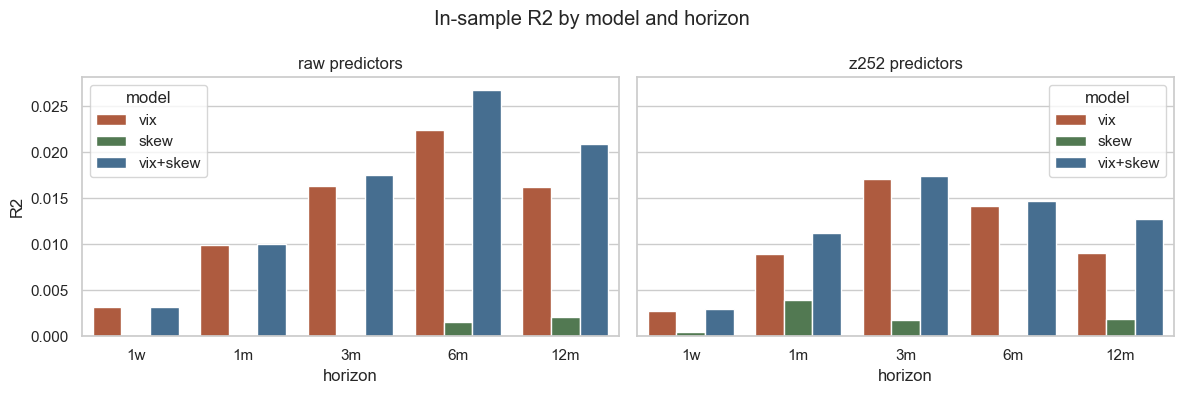

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, spec_name in zip(axes, specs):
    sub = reg_results[reg_results['spec'] == spec_name]
    sns.barplot(data=sub, x='horizon', y='r2', hue='model', order=list(HORIZONS), ax=ax,
                palette=['#c0522d', '#4c7f4c', '#3a6f9c'])
    ax.set_title(f'{spec_name} predictors')
    ax.set_ylabel('R2' if ax is axes[0] else '')
fig.suptitle('In-sample R2 by model and horizon')
fig.tight_layout()
plt.show()

### 8.3 Top-vs-bottom quintile spread test

Welch's t-test (unequal variance) on the difference in mean forward return between the top and
bottom quintile of each predictor, for each horizon.

In [13]:
spread_rows = []
for p in ['vix', 'vix_z252', 'skew', 'skew_z252']:
    for name in HORIZONS:
        sub = df[[p, f'fwd_ret_{name}']].dropna().copy()
        sub['q'] = pd.qcut(sub[p], 5, labels=False)
        top = sub.loc[sub['q'] == 4, f'fwd_ret_{name}']
        bottom = sub.loc[sub['q'] == 0, f'fwd_ret_{name}']
        t, pval = stats.ttest_ind(top, bottom, equal_var=False)
        spread_rows.append({
            'predictor': p, 'horizon': name,
            'q5_mean': top.mean(), 'q1_mean': bottom.mean(),
            'spread': top.mean() - bottom.mean(), 't_stat': t, 'p_value': pval,
        })
spread_results = pd.DataFrame(spread_rows)
spread_results.round(4)

,predictor,horizon,q5_mean,q1_mean,spread,t_stat,p_value
0,vix,1w,0.0043,0.0019,0.0024,2.6008,0.0094
1,vix,1m,0.0191,0.0087,0.0105,6.3940,0.0000
2,vix,3m,0.0533,0.0279,0.0254,10.1618,0.0000
3,vix,6m,0.0977,0.0637,0.0340,9.9197,0.0000
4,vix,12m,0.1562,0.1310,0.0253,4.6487,0.0000
5,vix_z252,1w,0.0042,0.0011,0.0031,3.4826,0.0005
6,vix_z252,1m,0.0167,0.0059,0.0108,6.9310,0.0000
7,vix_z252,3m,0.0440,0.0209,0.0231,9.5097,0.0000
8,vix_z252,6m,0.0788,0.0541,0.0247,7.2300,0.0000
9,vix_z252,12m,0.1357,0.1121,0.0236,4.0336,0.0001


## 9. Summary

**VIX (raw level and 252d z-score)** is the more informative of the two series. Its Pearson/Spearman
correlations with forward SPXTR returns are positive, small-to-moderate (Spearman rho ~ 0.07-0.14),
and highly significant (p < 0.0001) at *every* horizon from 1 week to 12 months - high VIX tends to
precede above-average subsequent returns, consistent with the well-documented volatility risk
premium / mean-reversion effect. The top-vs-bottom VIX quintile spread is large and significant too
(e.g. +2.5pp at 3m, t ~ 10, p < 0.0001).

**SKEW (raw level)** is much weaker: essentially flat and insignificant at 1w/1m, and only
significant from 3m onward, with a smaller effect size than VIX. **SKEW's 252d z-score** is more
interesting but not uniformly helpful - it is *negatively* and significantly related to forward
returns at 1w-3m (elevated tail-risk pricing relative to its own recent history slightly precedes
softer near-term returns), then flips positive and marginal at 12m. The sign flip across horizons
means SKEW does not have a stable, single-direction forecasting relationship the way VIX does.

**Correcting for overlap autocorrelation changes the picture.** The correlation/quintile tests above
treat each daily observation as independent, which is not true for overlapping forward returns and
overstates significance. Re-running the same regressions with Newey-West/HAC standard errors
(`maxlags = horizon`) is much less forgiving:
- VIX (raw) is **not** significant at any horizon once HAC-corrected (p ranges ~ 0.09-0.21).
- VIX (252d z-score) is significant only at 1m and 3m (p ~ 0.03-0.04); not at 1w, 6m, or 12m.
- SKEW (raw or z-score) is **never** significant under HAC, at any horizon, alone or combined with VIX.
- Combining VIX + SKEW barely moves R2 versus VIX alone (e.g. 3m: R2 0.0164 -> 0.0175), and SKEW's
  coefficient/p-value is unchanged by the addition - it contributes no incremental information once
  autocorrelation is properly accounted for.

**Bottom line:** VIX carries a real but modest, horizon-dependent forecasting signal for SPXTR
forward returns (strongest, and marginally significant even after HAC correction, at the 1-3 month
horizon). SKEW adds essentially nothing incremental to VIX, and on its own has an unstable,
often-insignificant relationship whose sign even reverses across horizons. Naive significance
testing (plain correlation, quintile t-tests) meaningfully overstates how forecastable SPXTR returns
are from either series - the HAC-adjusted regressions are the more trustworthy read.